In [9]:
import sys
sys.path.append("../ai-service")

import json
import numpy    as np
import torch
import matplotlib.pyplot as plt
import onnxruntime as ort
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Professor notebook environment ready")

Professor notebook environment ready


In [10]:
meta_path = Path("../ai-service/app/models/professor/rubric_suite_multimodal/v1/metadata.json")
onnx_path = Path("../ai-service/app/models/professor/rubric_suite_multimodal/v1/model.onnx")
prof_test_path = Path("../ai-service/datasets/processed/prof_multimodal_v1/test.pt")

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

prof_data = torch.load(prof_test_path, map_location="cpu")

print("Professor samples:", len(prof_data))
print("Professor sample keys:", list(prof_data[0].keys()))
print("Head order:", meta["head_order"])
print("Available label maps:", list(meta["label_maps"].keys()))

Professor samples: 5515
Professor sample keys: ['text_emb', 'ocr_emb', 'audio_emb', 'table_emb', 'mask', 'labels']
Head order: ['rubric_band', 'argument_depth', 'moderation_consistency']
Available label maps: ['rubric_band', 'argument_depth', 'moderation_consistency']


In [11]:
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])

print("Inputs:")
for i in session.get_inputs():
    print(i.name, i.shape, i.type)

print("\nOutputs:")
for o in session.get_outputs():
    print(o.name, o.shape, o.type)

Inputs:
text_emb ['batch', 384] tensor(float)
ocr_emb ['batch', 384] tensor(float)
audio_emb ['batch', 384] tensor(float)
table_emb ['batch', 64] tensor(float)
mask ['batch', 4] tensor(bool)

Outputs:
rubric_band [1, 3] tensor(float)
argument_depth [1, 4] tensor(float)
moderation_consistency [1, 3] tensor(float)


In [12]:
def evaluate_professor_head(head_name: str):
    y_true = []
    y_pred = []

    for batch in prof_data:
        inputs = {
            "text_emb": batch["text_emb"].unsqueeze(0).numpy().astype("float32"),
            "ocr_emb": batch["ocr_emb"].unsqueeze(0).numpy().astype("float32"),
            "audio_emb": batch["audio_emb"].unsqueeze(0).numpy().astype("float32"),
            "table_emb": batch["table_emb"].unsqueeze(0).numpy().astype("float32"),
            "mask": batch["mask"].unsqueeze(0).numpy().astype(bool),
        }

        outputs = session.run(None, inputs)
        output_names = [o.name for o in session.get_outputs()]
        output_map = dict(zip(output_names, outputs))

        logits = output_map[head_name]
        pred = int(np.argmax(logits, axis=1)[0])
        true_label = int(batch["labels"][head_name])

        y_pred.append(pred)
        y_true.append(true_label)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    label_map = meta["label_maps"][head_name]
    class_names = [label_map[str(i)] for i in sorted(map(int, label_map.keys()))]

    print("Head:", head_name)
    print("Predictions generated:", len(y_true))
    print("Unique true labels:", np.unique(y_true))
    print("Unique predicted labels:", np.unique(y_pred))
    print("Class names:", class_names)

    return y_true, y_pred, class_names

In [13]:
head_name = "rubric_band"
y_true, y_pred, class_names = evaluate_professor_head(head_name)

Head: rubric_band
Predictions generated: 5515
Unique true labels: [0 1 2]
Unique predicted labels: [0 1 2]
Class names: ['ineffective', 'adequate', 'effective']


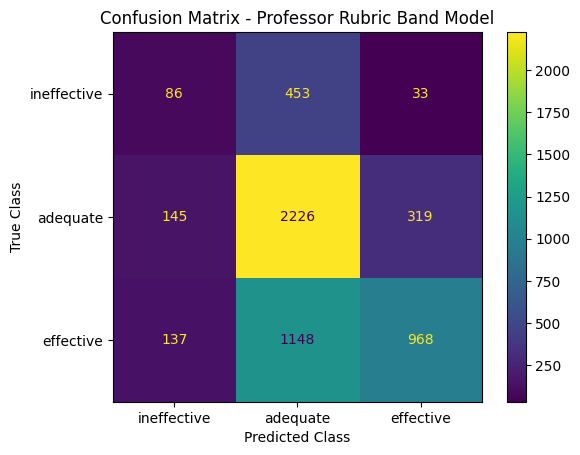

In [14]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()

plt.title("Confusion Matrix - Professor Rubric Band Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

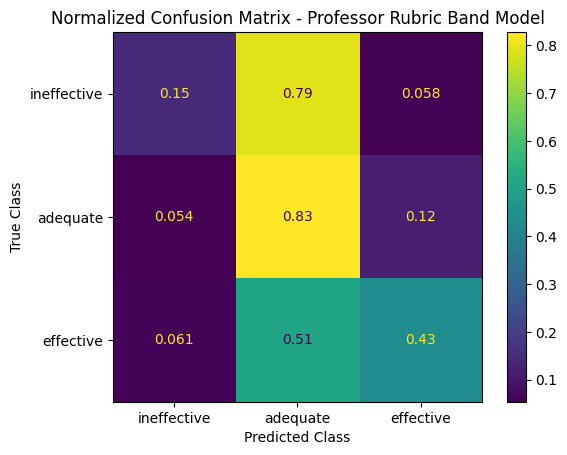

In [15]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot()

plt.title("Normalized Confusion Matrix - Professor Rubric Band Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [16]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 ineffective       0.23      0.15      0.18       572
    adequate       0.58      0.83      0.68      2690
   effective       0.73      0.43      0.54      2253

    accuracy                           0.59      5515
   macro avg       0.52      0.47      0.47      5515
weighted avg       0.61      0.59      0.57      5515



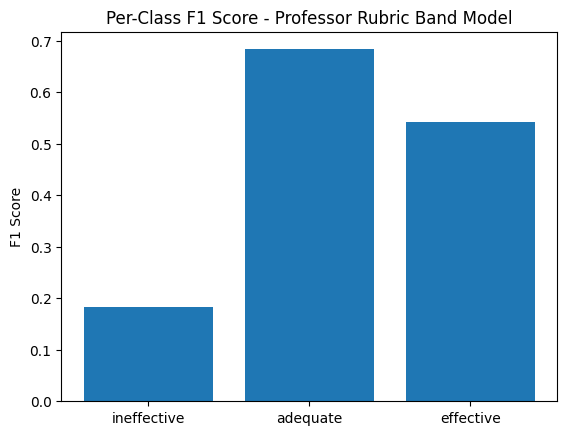

In [17]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
f1_scores = [report_dict[name]["f1-score"] for name in class_names]

plt.figure()
plt.bar(class_names, f1_scores)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score - Professor Rubric Band Model")
plt.show()

In [18]:
accuracy = report_dict["accuracy"]
macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Accuracy: 0.5947
Macro F1: 0.4693
Weighted F1: 0.5735


In [19]:
head_name = "argument_depth"
y_true, y_pred, class_names = evaluate_professor_head(head_name)

Head: argument_depth
Predictions generated: 5515
Unique true labels: [0 1 2 3]
Unique predicted labels: [0 1 2 3]
Class names: ['shallow', 'basic', 'developed', 'deep']


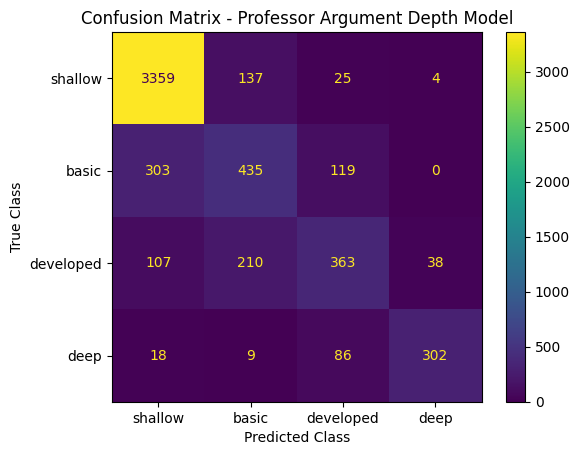

In [20]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()

plt.title("Confusion Matrix - Professor Argument Depth Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [21]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     shallow       0.89      0.95      0.92      3525
       basic       0.55      0.51      0.53       857
   developed       0.61      0.51      0.55       718
        deep       0.88      0.73      0.80       415

    accuracy                           0.81      5515
   macro avg       0.73      0.67      0.70      5515
weighted avg       0.80      0.81      0.80      5515



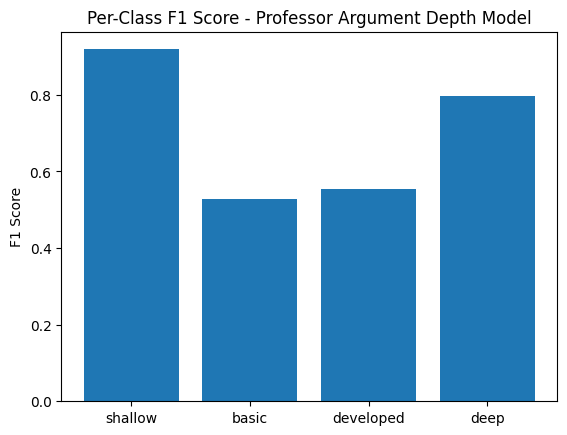

In [23]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
f1_scores = [report_dict[name]["f1-score"] for name in class_names]

plt.figure()
plt.bar(class_names, f1_scores)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score - Professor Argument Depth Model")
plt.show()

In [24]:
head_name = "moderation_consistency"
y_true, y_pred, class_names = evaluate_professor_head(head_name)

Head: moderation_consistency
Predictions generated: 5515
Unique true labels: [0 1 2]
Unique predicted labels: [1 2]
Class names: ['inconsistent', 'mixed', 'consistent']


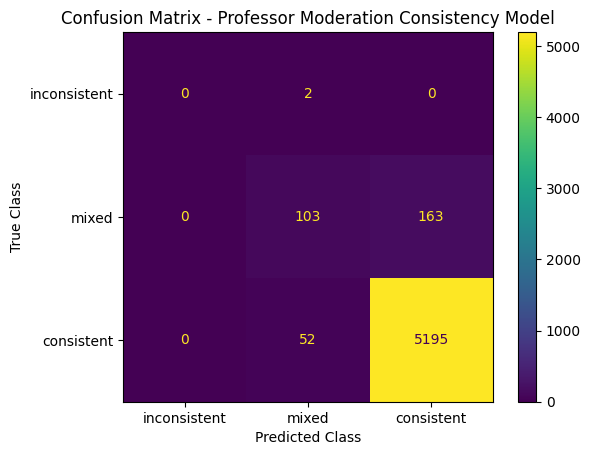

In [25]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()

plt.title("Confusion Matrix - Professor Moderation Consistency Model")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [26]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

inconsistent       0.00      0.00      0.00         2
       mixed       0.66      0.39      0.49       266
  consistent       0.97      0.99      0.98      5247

    accuracy                           0.96      5515
   macro avg       0.54      0.46      0.49      5515
weighted avg       0.95      0.96      0.96      5515



c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sahua\OneDrive\Desktop\ANSH\EduAIPlatform\ai-service\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

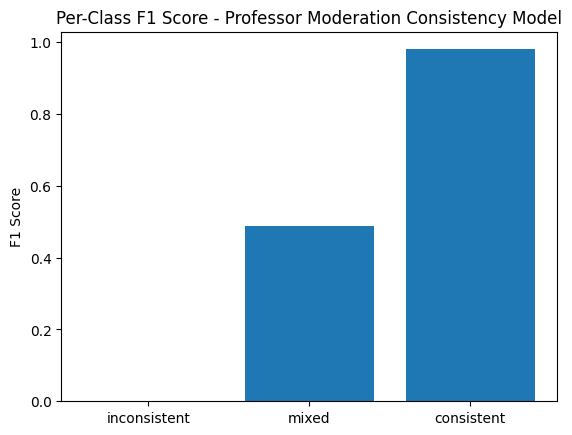

In [27]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
f1_scores = [report_dict[name]["f1-score"] for name in class_names]

plt.figure()
plt.bar(class_names, f1_scores)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score - Professor Moderation Consistency Model")
plt.show()

In [28]:
plt.savefig("professor_rubric_band_confusion_matrix.png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

In [30]:
## Professor Multitask Model Evaluation
#The professor-facing multimodal model was evaluated using an ONNX deployment artifact trained on the `prof_multimodal_v1` dataset. Unlike the student model, this architecture is multitask and produces three separate outputs: rubric band, argument depth, and moderation consistency. Each output head operates on the same fused multimodal representation derived from text, OCR, audio, and table features.
###The moderation consistency head predicts whether evaluation outcomes are inconsistent, borderline, or consistent. This is valuable in the context of academic governance, as it connects the AI system to quality assurance and moderation-oriented use cases rather than only student-facing feedback generation.
#Compared with the student model, the professor model demonstrates a more advanced deployment configuration. The student model is a single-head multimodal classifier focused on feedback categories, whereas the professor model is a multitask ONNX system designed to support multiple academic evaluation objectives through one shared multimodal backbone.
